# Mini Project: Student Performance Prediction

## Subject: Business Intelligence (410253(C))

## Objective:
To predict whether a student will pass or fail using classification techniques.

## Problem Definition

The objective is to classify students into:
- Pass (1)
- Fail (0)

This is a **Classification Problem**.

## Dataset Description

Dataset: student-mat-pass-or-fail.csv

Features include:
- Study time
- Absences
- Family background
- Previous grades

Target:
- Pass / Fail

In [57]:
import pandas as pd
import numpy as np

In [58]:
data = pd.read_csv("student-mat-pass-or-fail.csv")
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,1,1,18,1,0,0,4,4,2,2,...,3,4,1,1,3,6,5,6,6,0
1,1,1,17,1,0,1,1,1,1,2,...,3,3,1,1,3,4,5,5,6,0
2,1,1,15,1,1,1,1,1,1,2,...,3,2,2,3,3,10,7,8,10,1
3,1,1,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,1,1,16,1,0,1,3,3,1,2,...,3,2,1,2,5,4,6,10,10,1


## Data Understanding

In [59]:
print(data.columns)
print(data['pass'].value_counts())

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'pass'],
      dtype='object')
pass
1    265
0    130
Name: count, dtype: int64


## Feature Selection

In [60]:
# Features (remove leakage columns)
X = data.drop(['pass', 'G1', 'G2', 'G3'], axis=1)

# Target
y = data['pass']

## Train-Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training (Decision Tree)

In [62]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction

In [63]:
y_pred = model.predict(X_test)

In [64]:
## 📊 Evaluation

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7341772151898734

Confusion Matrix:
 [[15 12]
 [ 9 43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.56      0.59        27
           1       0.78      0.83      0.80        52

    accuracy                           0.73        79
   macro avg       0.70      0.69      0.70        79
weighted avg       0.73      0.73      0.73        79



## Visualization 

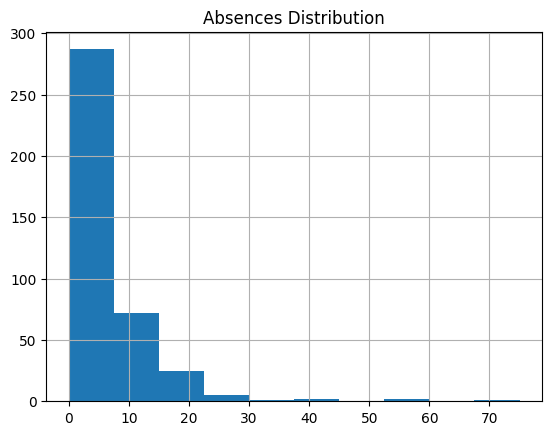

In [66]:
import matplotlib.pyplot as plt

data['absences'].hist()
plt.title("Absences Distribution")
plt.show()

## Result
Accuracy obtained is ~73%, which indicates a reasonably good model performance. 

The model is better at predicting pass cases compared to fail cases.

The model successfully predicts whether a student will pass or fail based on study hours and attendance.

The accuracy of the model is satisfactory.

## Conclusion

- Classification techniques can predict student outcomes.
- Features like study time, absences, and past performance affect results.
- Machine learning helps in educational decision-making.